# Sample data access

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
from arraylake import Client
import zarr

from matplotlib import pyplot as plt
import matplotlib as mpl
import cartopy
from cartopy import crs as ccrs
import cmocean

## Accessing 1$^\circ$ bias-corrected time series 

## Setup

An Earthmover account is necessary to access the data. You can sign up at [earthmover.io](earthmover.io) with Github, Google, or email.

Once signed up, authenticate in the notebook:

In [3]:
# Start ArrayLake client
client = Client()

#authenticate sign-up for Earthmover:
client.login(browser=False)  

# Start session to access 1-deg bias-corrected data
repo = client.get_repo("ClimateUncertaintyLab/bcd_me_qdm")
session = repo.readonly_session(branch="main")

# Get list of available models
modlist = list(zarr.open_group(session.store,mode='r').group_keys())
print(modlist)


['ACCESS-ESM1-5', 'CNRM-CM6-1', 'CESM2-WACCM', 'EC-Earth3-Veg', 'FGOALS-g3', 'CanESM5', 'MRI-ESM2-0', 'EC-Earth3', 'MIROC6', 'MPI-ESM1-2-LR', 'IPSL-CM6A-LR', 'CNRM-ESM2-1']


In [3]:
# Open one model's worth of data 
mod = modlist[0]
print(f'Opening {mod}')
ds = xr.open_zarr(session.store, zarr_format=3, group=mod)
ds

Opening ACCESS-ESM1-5


<xarray.Dataset> Size: 5TB
Dimensions:        (idv: 25, proj_base: 4, lat: 142, lon: 360, gwl: 8,
                    dayofyear: 365, year: 20, variable: 2)
Coordinates:
    experiment     (idv) <U6 600B dask.array<chunksize=(25,), meta=np.ndarray>
    run            (idv) <U9 900B dask.array<chunksize=(25,), meta=np.ndarray>
    model          (idv) <U13 1kB dask.array<chunksize=(25,), meta=np.ndarray>
  * proj_base      (proj_base) <U6 96B 'ERA5' 'GMFD' 'JRA-3Q' 'MERRA2'
  * lat            (lat) float64 1kB -55.5 -54.5 -53.5 -52.5 ... 83.5 84.5 85.5
  * lon            (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * gwl            (gwl) float64 64B 0.61 1.0 1.5 2.0 2.5 3.0 3.5 4.0
    has_data       (variable, idv, gwl) bool 400B dask.array<chunksize=(2, 25, 8), meta=np.ndarray>
  * dayofyear      (dayofyear) int64 3kB 1 2 3 4 5 6 ... 360 361 362 363 364 365
  * year           (year) int64 160B 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
    calendar_year  (idv, gwl, year) float64 32kB dask.array<chunksize=(25, 8, 20), meta=np.ndarray>
  * variable       (variable) object 16B 'tas' 'tasmax'
Dimensions without coordinates: idv
Data variables:
    tas            (idv, proj_base, lat, lon, gwl, dayofyear, year) float64 2TB dask.array<chunksize=(1, 1, 40, 40, 1, 365, 20), meta=np.ndarray>
    tasmax         (idv, proj_base, lat, lon, gwl, dayofyear, year) float64 2TB dask.array<chunksize=(1, 1, 40, 40, 1, 365, 20), meta=np.ndarray>
Attributes:
    DESCRIPTION:  ACCESS-ESM1-5 ScenarioMIP runs, bias-corrected using Quanti...
    Project:      Bias-Corrected, Downscaled Massive Ensemble (BCD-ME)
    Creators:     Kevin Schwarzwald, Nathan Lenssen, Radley Horton, and Gerno...
    Version:      v1.0
    License:      CC BY 4.0

In [4]:
# Show which variables have data for which runs and which GWLs
has_data = ds.has_data.load()

max_gwls = has_data.gwl.isel(gwl=(has_data.argmin('gwl') - 1))
max_gwls = max_gwls.where(~((~has_data).all('gwl')))
max_gwls
for var in max_gwls['variable'].values:
    print(f'{var}: ')
    unique_maxgwls = np.unique(max_gwls.sel(variable=var))
    unique_maxgwls = unique_maxgwls[~np.isnan(unique_maxgwls)]
    for uval in unique_maxgwls:
        runs_tmp = np.where(max_gwls.sel(variable=var) >= uval)[0]
        print(f'   # of runs reaching at least GWL{str(uval)}: {str(len(runs_tmp))} (`idv`s: {', '.join([str(runid) for runid in runs_tmp])})')
    print('')

tas: 
   # of runs reaching at least GWL2.5: 24 (`idv`s: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24)
   # of runs reaching at least GWL4.0: 5 (`idv`s: 19, 20, 22, 23, 24)

tasmax: 
   # of runs reaching at least GWL4.0: 6 (`idv`s: 19, 20, 21, 22, 23, 24)



Data is chunked such that each chunk contains all days for one region (~ 40 degrees of lat / lon), one ensemble member, and one reanalysis, with the assumption that most processing would happen at the local, regional level first. Data queries made with this in mind tend to be faster.

In [22]:
# Load sample data: temperature for a region, over two GWLs and one reanalysis
ds_tmp = ds.sel(proj_base = 'ERA5',gwl=[0.61,2],lat=slice(10,50),lon=slice(-125,-65)).tas
ds_tmp = ds_tmp.load()

Text(0.5, 1.0, 'Change in Jan 1 temperature,\nGWL2 - GWL0.61, mean across ACCESS-ESM1-5 runs')

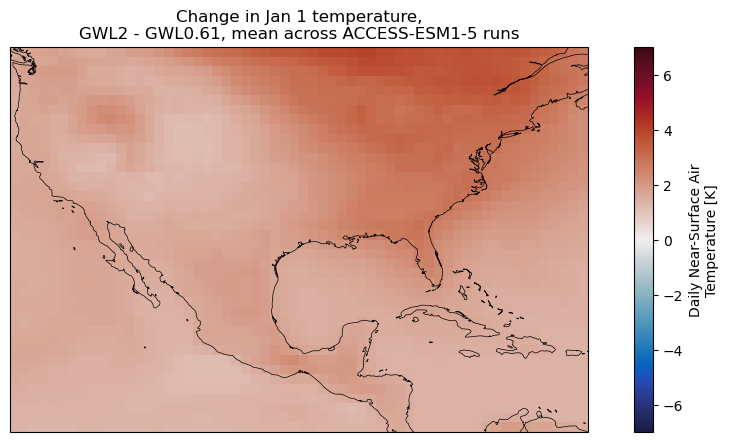

In [6]:
# Plot change in the daily mean temperature of January 1sts between GWL 0.61 
# and GWL 2 for one model, one projection base
fig = plt.figure(figsize=(12,5))

ax = plt.subplot(projection=ccrs.PlateCarree())

plot_data = ds_tmp.sel(gwl=2,dayofyear=1).mean(('idv','year')) - plot_data.sel(gwl=0.61,dayofyear=1).mean(('idv','year'))

plot_data.plot(transform=ccrs.PlateCarree(),cmap=cmocean.cm.balance,vmin=-7,vmax=7)
ax.coastlines(linewidth=0.5)

ax.set_title(f'Change in Jan 1 temperature,\nGWL2 - GWL0.61, mean across {mod} runs')

Text(0.5, 1.0, 'Time series of 20 years of daily T at GWL 0.61 in New York\nfor BCD-ME member ACCESS-ESM1-5, ssp245, r10i1p1f1')

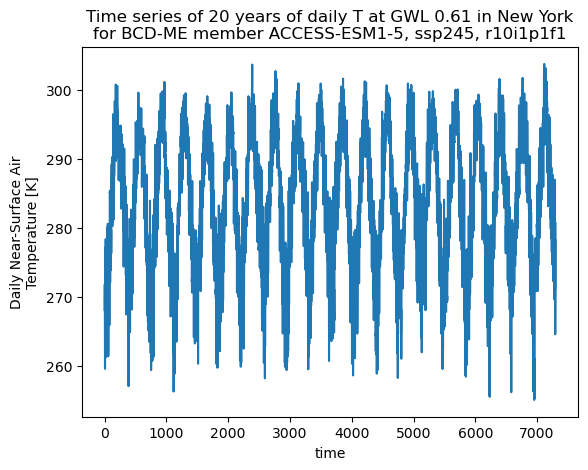

In [38]:
# Plot timeseries of a particular location
# Note that the time dimension is generic because of the GWL-based format.
ax = plt.subplot()
plot_data = ds_tmp.isel(idv=0,gwl=0).sel(lat=41,lon=-74,method='nearest').stack(time=['year','dayofyear']).reset_index('time')

plot_data.plot()
ax.set_title(f'Time series of 20 years of daily T at GWL {plot_data.gwl.values} in New York\n'+
             f'for BCD-ME member {', '.join([str(plot_data[v].values) for v in ['model','experiment','run']])}')

In [4]:
# Figure out which ensemble members have data for which GWLs, across all models
has_data_all = [xr.open_zarr(session.store, zarr_format=3, group=mod)
                for mod in modlist]
has_data_all = [hd.has_data for hd in has_data_all if 'has_data' in hd ]
has_data_all = xr.concat(has_data_all,dim='idv',join='outer').load()
has_data_all = has_data_all.where(~np.isnan(has_data_all),0)

In [5]:
has_data_all

<xarray.DataArray 'has_data' (variable: 2, idv: 295, gwl: 8)> Size: 38kB
array([[[1., 1., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 0., 0., 0.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(2, 295, 8))
Coordinates:
  * variable    (variable) object 16B 'tas' 'tasmax'
    run         (idv) <U9 11kB 'r10i1p1f1' 'r11i1p1f1' ... 'r2i1p1f1' 'r3i1p1f1'
    experiment  (idv) <U6 7kB 'ssp245' 'ssp245' 'ssp245' ... 'ssp585' 'ssp585'
    model       (idv) <U13 15kB 'ACCESS-ESM1-5' ... 'IPSL-CM6A-LR'
  * gwl         (gwl) float64 64B 0.61 1.0 1.5 2.0 2.5 3.0 3.5 4.0
    has_data    (variable, idv, gwl) float64 38kB 1.0 1.0 1.0 ... 0.0 0.0 0.0
Dimensions without coordinates: idv

## Accessing 0.25$^\circ$ downscaled statistics

In [39]:
# Start ArrayLake client
client = Client()

# Start session to access 0.25-deg downscaled data
repo = client.get_repo("ClimateUncertaintyLab/bcd_me_qdm_qplad")
session = repo.readonly_session(branch="main")

# Get list of available models
modlist = list(zarr.open_group(session.store,mode='r').group_keys())
print(modlist)


['ACCESS-ESM1-5', 'CESM2-WACCM', 'CNRM-ESM2-1', 'EC-Earth3', 'IPSL-CM6A-LR', 'EC-Earth3-Veg', 'FGOALS-g3', 'MPI-ESM1-2-LR', 'CanESM5', 'MIROC6', 'MRI-ESM2-0', 'CNRM-CM6-1']


In [41]:
# Open one model's worth of data 
mod = modlist[-1]
print(f'Opening {mod}')
# Set `decode_timedelta=False` - due to an xarray quirk, bin-days are assumed to be
# timedeltas instead of floats
ds = xr.open_zarr(session.store, zarr_format=3, group=mod,decode_timedelta=False)
ds

Opening CNRM-CM6-1


<xarray.Dataset> Size: 769GB
Dimensions:        (idv: 18, proj_base: 4, lat: 568, lon: 1440, gwl: 8,
                    binC: 73, binF: 27, degree: 4, bnds: 2, year: 20,
                    variable: 6)
Coordinates: (12/17)
    experiment     (idv) <U6 432B dask.array<chunksize=(18,), meta=np.ndarray>
    run            (idv) <U8 576B dask.array<chunksize=(18,), meta=np.ndarray>
    model          (idv) <U10 720B dask.array<chunksize=(18,), meta=np.ndarray>
  * proj_base      (proj_base) <U6 96B 'ERA5' 'GMFD' 'JRA-3Q' 'MERRA2'
  * lat            (lat) float64 5kB -55.88 -55.62 -55.38 ... 85.38 85.62 85.88
  * lon            (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
    ...             ...
  * bnds           (bnds) int64 16B 0 1
    binC_bnds      (binC, bnds) float64 1kB dask.array<chunksize=(73, 2), meta=np.ndarray>
    binF_bnds      (binF, bnds) float64 432B dask.array<chunksize=(27, 2), meta=np.ndarray>
  * year           (year) int64 160B 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
    calendar_year  (idv, gwl, year) float64 23kB dask.array<chunksize=(18, 8, 20), meta=np.ndarray>
  * variable       (variable) object 48B 'tasbinC' ... 'tasmaxsumpoly'
Dimensions without coordinates: idv
Data variables:
    tasbinC        (idv, proj_base, lat, lon, gwl, binC) float64 275GB dask.array<chunksize=(1, 1, 200, 250, 1, 73), meta=np.ndarray>
    tasmaxbinF     (idv, proj_base, lat, lon, gwl, binF) float64 102GB dask.array<chunksize=(1, 1, 200, 250, 1, 27), meta=np.ndarray>
    tasmaxsumpoly  (idv, proj_base, lat, lon, gwl, degree) float32 8GB dask.array<chunksize=(1, 1, 200, 250, 1, 4), meta=np.ndarray>
    tassumpoly     (idv, proj_base, lat, lon, gwl, degree) float32 8GB dask.array<chunksize=(1, 1, 200, 250, 1, 4), meta=np.ndarray>
    tasmaxbinC     (idv, proj_base, lat, lon, gwl, binC) float64 275GB dask.array<chunksize=(1, 1, 200, 250, 1, 73), meta=np.ndarray>
    tasbinF        (idv, proj_base, lat, lon, gwl, binF) float64 102GB dask.array<chunksize=(1, 1, 200, 250, 1, 27), meta=np.ndarray>
Attributes:
    DESCRIPTION:  CNRM-CM6-1 statistics of ScenarioMIP runs, bias-corrected u...
    Project:      Bias-Corrected, Downscaled Massive Ensemble (BCD-ME)
    Creators:     Kevin Schwarzwald, Nathan Lenssen, Radley Horton, and Gerno...
    Version:      v1.0
    License:      CC BY 4.0

In [43]:
# Show which variables have data for which runs and which GWLs
has_data = ds.has_data.load()

max_gwls = has_data.gwl.isel(gwl=(has_data.argmin('gwl') - 1))
max_gwls = max_gwls.where(~((~has_data).all('gwl')))
max_gwls
for var in max_gwls['variable'].values:
    print(f'{var}: ')
    unique_maxgwls = np.unique(max_gwls.sel(variable=var))
    unique_maxgwls = unique_maxgwls[~np.isnan(unique_maxgwls)]
    for uval in unique_maxgwls:
        runs_tmp = np.where(max_gwls.sel(variable=var) >= uval)[0]
        print(f'   # of runs reaching at least GWL{str(uval)}: {str(len(runs_tmp))} (`idv`s: {', '.join([str(runid) for runid in runs_tmp])})')
    print('')

tasbinC: 
   # of runs reaching at least GWL2.5: 18 (`idv`s: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17)
   # of runs reaching at least GWL3.0: 15 (`idv`s: 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17)
   # of runs reaching at least GWL3.5: 12 (`idv`s: 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17)
   # of runs reaching at least GWL4.0: 6 (`idv`s: 12, 13, 14, 15, 16, 17)

tassumpoly: 
   # of runs reaching at least GWL2.5: 18 (`idv`s: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17)
   # of runs reaching at least GWL3.0: 15 (`idv`s: 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17)
   # of runs reaching at least GWL3.5: 12 (`idv`s: 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17)
   # of runs reaching at least GWL4.0: 6 (`idv`s: 12, 13, 14, 15, 16, 17)

tasbinF: 
   # of runs reaching at least GWL2.5: 18 (`idv`s: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17)
   # of runs reaching at least GWL3.0: 15 (`idv`s: 1, 4, 5, 6, 7, 8, 9, 10, 11, 

Let's take a look at the chunking of one of these variables, below. Note that data requests that minimize the number of chunks will be more efficient.

In [70]:
ds.tasbinC

<xarray.DataArray 'tasbinC' (idv: 18, proj_base: 4, lat: 568, lon: 1440,
                             gwl: 8, binC: 73)> Size: 275GB
dask.array<open_dataset-tasbinC, shape=(18, 4, 568, 1440, 8, 73), dtype=float64, chunksize=(1, 1, 200, 250, 1, 73), chunktype=numpy.ndarray>
Coordinates:
    experiment  (idv) <U6 432B 'ssp245' 'ssp245' 'ssp245' ... 'ssp585' 'ssp585'
    run         (idv) <U8 576B 'r1i1p1f2' 'r2i1p1f2' ... 'r5i1p1f2' 'r6i1p1f2'
    model       (idv) <U10 720B 'CNRM-CM6-1' 'CNRM-CM6-1' ... 'CNRM-CM6-1'
  * proj_base   (proj_base) <U6 96B 'ERA5' 'GMFD' 'JRA-3Q' 'MERRA2'
  * lat         (lat) float64 5kB -55.88 -55.62 -55.38 ... 85.38 85.62 85.88
  * lon         (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * gwl         (gwl) float64 64B 0.61 1.0 1.5 2.0 2.5 3.0 3.5 4.0
  * binC        (binC) float64 584B -21.0 -20.0 -19.0 -18.0 ... 49.0 50.0 51.0
Dimensions without coordinates: idv
Attributes:
    long_name:      Days With Mean Near-Surface Air Temperature in Celsius Bins
    standard_name:  C_bin_days
    units:          days

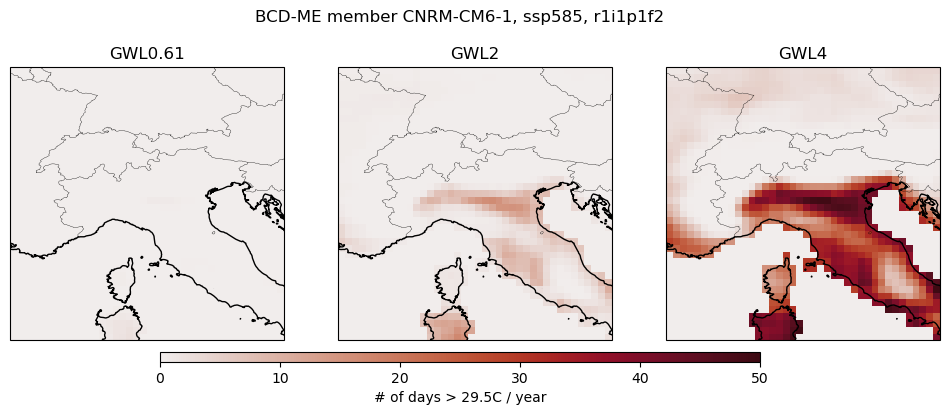

In [69]:
# Lets get the change in number of days above 29.5 degrees per year
# over one stretch in continental Europe
fig = plt.figure(figsize=(12,4))

cbar_params = {'vmin':0,'vmax':50,
               'cmap':cmocean.cm.amp}

for plt_idx,gwl in enumerate([0.61,2,4]):
    plot_data = ds.tasbinC.isel(idv=12).sel(proj_base = 'JRA-3Q',binC = slice(30,None),
                                lat=slice(40,50),lon=slice(5,15),gwl=gwl).sum('binC')

    ax = plt.subplot(1,3,plt_idx+1,projection=ccrs.PlateCarree())

    plot_data.plot(transform=ccrs.PlateCarree(),**cbar_params,add_colorbar=False)
    ax.coastlines()

    ax.set_title(f'GWL{str(gwl)}')


    ax.add_feature(cartopy.feature.BORDERS, linestyle='-',linewidth=0.25)

fig.suptitle(f'BCD-ME member {', '.join([str(plot_data[v].values) for v in ['model','experiment','run']])}')

# Add horizontal colorbar
#fig.subplots_adjust(right=0.825)
cax = fig.add_axes([0.25, 0.1, 0.5, 0.025])
norm = mpl.colors.Normalize(vmin=cbar_params['vmin'],vmax=cbar_params['vmax'])
sm = plt.cm.ScalarMappable(cmap=cbar_params['cmap'],norm=norm)
plt.colorbar(sm,cax=cax,label = '# of days > 29.5C / year',orientation='horizontal')

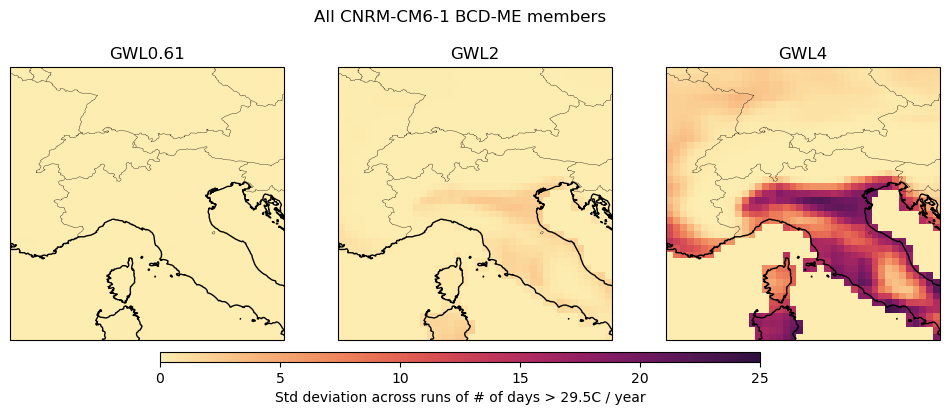

In [68]:
# Now, let's plot the internal variability in the same, across runs of this model!
fig = plt.figure(figsize=(12,4))

cbar_params = {'vmin':0,'vmax':25,
               'cmap':cmocean.cm.matter}

for plt_idx,gwl in enumerate([0.61,2,4]):
    plot_data = ds.tasbinC.sel(proj_base = 'JRA-3Q',binC = slice(30,None),
                                lat=slice(40,50),lon=slice(5,15),gwl=gwl).sum('binC').std('idv')

    ax = plt.subplot(1,3,plt_idx+1,projection=ccrs.PlateCarree())

    plot_data.plot(transform=ccrs.PlateCarree(),**cbar_params,add_colorbar=False)
    ax.coastlines()

    ax.set_title(f'GWL{str(gwl)}')


    ax.add_feature(cartopy.feature.BORDERS, linestyle='-',linewidth=0.25)

fig.suptitle(f'All {mod} BCD-ME members')

# Add horizontal colorbar
#fig.subplots_adjust(right=0.825)
cax = fig.add_axes([0.25, 0.1, 0.5, 0.025])
norm = mpl.colors.Normalize(vmin=cbar_params['vmin'],vmax=cbar_params['vmax'])
sm = plt.cm.ScalarMappable(cmap=cbar_params['cmap'],norm=norm)
plt.colorbar(sm,cax=cax,label = 'Std deviation across runs of # of days > 29.5C / year',orientation='horizontal')